<a href="https://colab.research.google.com/github/mianorris314/RUSH-analytics/blob/code-edits-mianorris/GENBUS885_Final_Norris_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RUSH Analytics

Mia Norris

RUSH is a globally renowned sportswear and footwear brand known for its innovative designs and performance-oriented products. The company stores its raw sales data as a collection of three tables:

- TABLE_PRODUCTS
- TABLE_RETAILER
- TABLE_SALES

In [1]:
#Importing the relevant libraries
import numpy as np
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Set up the tables
uploaded = files.upload()

Saving TABLE_PRODUCTS_885.csv to TABLE_PRODUCTS_885 (3).csv
Saving TABLE_RETAILER_885.csv to TABLE_RETAILER_885 (3).csv
Saving TABLE_SALES_885.csv to TABLE_SALES_885 (3).csv


In [3]:
products_df = pd.read_csv("TABLE_PRODUCTS_885.csv", sep="|")
products_df.head()

,PRODUCT_ID,PRODUCT_NAME
0,20,Men's Street Footwear
1,30,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,40,Men's Apparel


In [4]:
sales_df = pd.read_csv('TABLE_SALES_885.csv')
sales_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet


In [5]:
retailer_df = pd.read_csv('TABLE_RETAILER_885.csv')
retailer_df.head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


**Data Inspection**

Checking for data types

In [6]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PRODUCT_ID    6 non-null      int64 
 1   PRODUCT_NAME  6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [7]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          9648 non-null   int64  
 1   RETAILER_ID       9648 non-null   object 
 2   INVOICE_DATE      9648 non-null   object 
 3   MONTH             9648 non-null   int64  
 4   DAY               9648 non-null   int64  
 5   YEAR              9648 non-null   int64  
 6   PRODUCT_ID        9648 non-null   int64  
 7   PRICE_PER_UNIT    9646 non-null   float64
 8   UNITS_SOLD        9648 non-null   object 
 9   OPERATING_MARGIN  9648 non-null   float64
 10  SALES_METHOD      9648 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 829.3+ KB


In [8]:
retailer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   RETAILER_ID  110 non-null    object
 1   RETAILER     110 non-null    object
 2   REGION       110 non-null    object
 3   STATE        110 non-null    object
 4   CITY         110 non-null    object
dtypes: object(5)
memory usage: 4.4+ KB


Checking for null values

In [9]:
products_df.isnull().sum()

,0
PRODUCT_ID,0
PRODUCT_NAME,0


In [10]:
sales_df.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,2
UNITS_SOLD,0
OPERATING_MARGIN,0


In [11]:
retailer_df.isnull().sum()

,0
RETAILER_ID,0
RETAILER,0
REGION,0
STATE,0
CITY,0


Looking for erroneous values and outliers

In [12]:
products_df.describe()

,PRODUCT_ID
count,6.000000
mean,80.000000
std,55.497748
min,20.000000
25%,32.500000
50%,80.000000
75%,127.500000
max,140.000000


In [13]:
sales_df.describe()

,ORDER_ID,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,OPERATING_MARGIN
count,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9646.000000,9648.000000
mean,4824.500000,6.458126,14.696310,2020.865050,79.975124,55.575264,0.422991
std,2785.282032,3.454799,7.348019,0.341688,50.668992,1017.819943,0.097197
min,1.000000,1.000000,1.000000,2020.000000,20.000000,7.000000,0.100000
25%,2412.750000,3.000000,9.000000,2021.000000,30.000000,35.000000,0.350000
50%,4824.500000,6.000000,15.000000,2021.000000,40.000000,45.000000,0.410000
75%,7236.250000,9.000000,21.000000,2021.000000,130.000000,55.000000,0.490000
max,9648.000000,12.000000,31.000000,2021.000000,140.000000,99999.000000,0.800000


In [14]:
retailer_df.describe()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
count,110,110,110,110,110
unique,106,6,5,50,52
top,W00SFLOR,Foot Locker,Northeast,Florida,Charleston
freq,2,33,28,6,4


**Data Inspection Findings:** <br>
- all three dataframes can be merged into one for easier analysis

sales_df
- units sold has two rows with *** instead of a number
- invoice data should be converted to a date object
- there are two nulls in price per unit

retailer_df
- there are 110 retailer_ids and 106 unique values

**Data Cleaning**

sales_df cleaning

In [15]:
#units sold has two rows with *** instead of a number
#coerce so that '***' becomes NaN
sales_df["UNITS_SOLD"] = pd.to_numeric(sales_df["UNITS_SOLD"], errors="coerce")

#dropping these rows since this is an extremely important data point
sales_df = sales_df.dropna(subset=["UNITS_SOLD"])

#cast the remaining values to an integer
sales_df["UNITS_SOLD"] = sales_df["UNITS_SOLD"].astype(int)

In [16]:
#invoice data should be converted to a date object
sales_df["INVOICE_DATE"] = pd.to_datetime(sales_df["INVOICE_DATE"])
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9646 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDER_ID          9646 non-null   int64         
 1   RETAILER_ID       9646 non-null   object        
 2   INVOICE_DATE      9646 non-null   datetime64[ns]
 3   MONTH             9646 non-null   int64         
 4   DAY               9646 non-null   int64         
 5   YEAR              9646 non-null   int64         
 6   PRODUCT_ID        9646 non-null   int64         
 7   PRICE_PER_UNIT    9644 non-null   float64       
 8   UNITS_SOLD        9646 non-null   int64         
 9   OPERATING_MARGIN  9646 non-null   float64       
 10  SALES_METHOD      9646 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(6), object(2)
memory usage: 904.3+ KB


In [17]:
#there are two nulls in price per unit
#filling price per unit with the median for that product
sales_df["PRICE_PER_UNIT"] = sales_df["PRICE_PER_UNIT"].fillna(
    sales_df.groupby("PRODUCT_ID")["PRICE_PER_UNIT"].transform("median")
)
sales_df.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,0
UNITS_SOLD,0
OPERATING_MARGIN,0


retailer_df cleaning

In [18]:
#there are 110 retailer_ids and 106 unique values
#isolate the problem rows to review
dupes = retailer_df[retailer_df.duplicated(subset=["RETAILER_ID"], keep=False)].sort_values("RETAILER_ID")
print(dupes)

    RETAILER_ID       RETAILER     REGION       STATE         CITY
63     S00NNENE  Sports Direct  Northeast  New Jersey       Newark
64     S00NNENE  Sports Direct  Northeast    New York     New York
81     W00SARLI        Walmart      South    Arkansas  Little Rock
97     W00SARLI      West Gear      South    Arkansas  Little Rock
84     W00SFLOR        Walmart  Southeast     Florida      Orlando
102    W00SFLOR      West Gear  Southeast     Florida      Orlando
83     W00STEHO        Walmart      South       Texas      Houston
100    W00STEHO      West Gear      South       Texas      Houston


4 retailer IDs were non-unique in the source data, meaning region/city-level results for those ~623 transactions may not be fully accurate. Since I am unsure which data is correct, I will leave the values in the dataset as they are.

Merging the tables for easier analysis

In [19]:
full_df = sales_df.merge(retailer_df, on="RETAILER_ID", how="left").merge(products_df, on="PRODUCT_ID", how="left")
full_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
0,1,A00MOHCO,2020-01-01,1,1,2020,20,50.0,1200,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
1,7,A00MOHCO,2020-01-07,1,7,2020,20,50.0,1250,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
2,13,A00MOHCO,2020-01-25,1,25,2020,20,50.0,1220,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
3,19,A00MOHCO,2020-01-31,1,31,2020,20,50.0,1200,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
4,25,A00MOHCO,2020-02-06,2,6,2020,20,60.0,1220,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear


**Data Analysis for Trends**

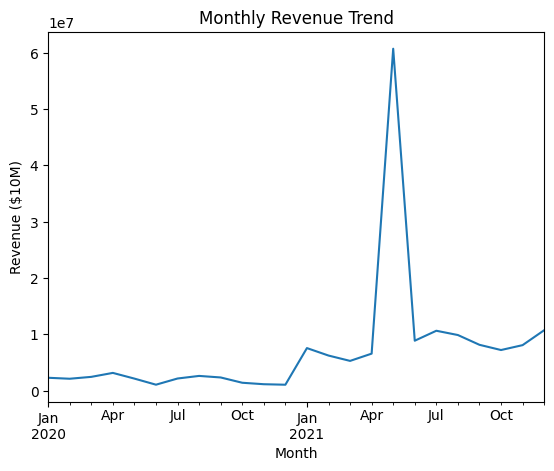

In [20]:
#monthly analysis of revenue
full_df["REVENUE"] = full_df["UNITS_SOLD"] * full_df["PRICE_PER_UNIT"]
monthly_revenue = full_df.groupby(full_df["INVOICE_DATE"].dt.to_period("M"))["REVENUE"].sum()
monthly_revenue.plot(title="Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($10M)")
plt.show()

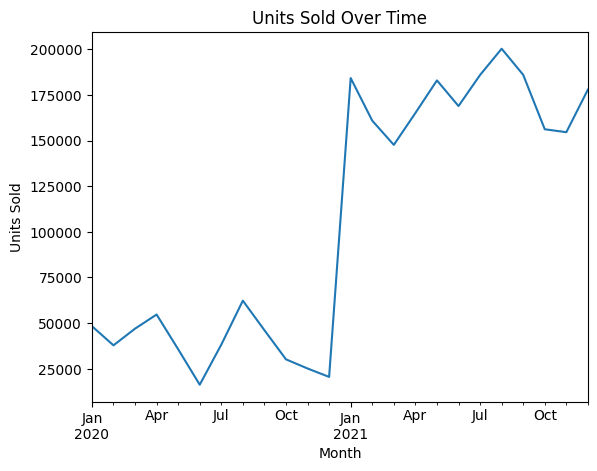

In [21]:
#units sold over time
units_over_time = full_df.groupby(full_df["INVOICE_DATE"].dt.to_period("M"))["UNITS_SOLD"].sum()
units_over_time.plot(title="Units Sold Over Time")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

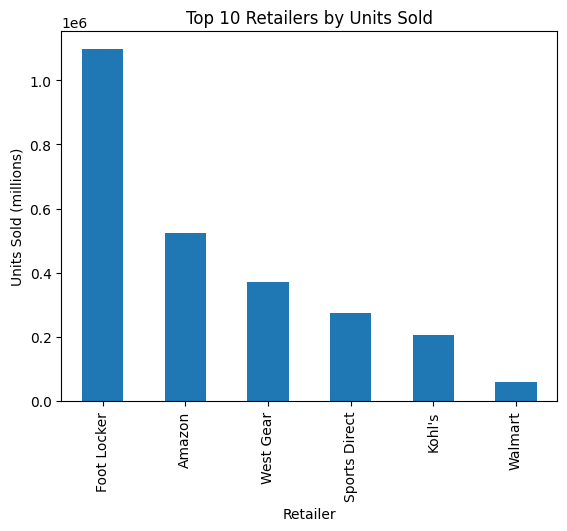

In [22]:
# Top 10 retailers by units sold
retailer_units = full_df.groupby("RETAILER")["UNITS_SOLD"].sum().sort_values(ascending=False)
top_retailers = retailer_units.head(10)

top_retailers.plot(kind="bar", title="Top 10 Retailers by Units Sold")
plt.xlabel("Retailer")
plt.ylabel("Units Sold (millions)")
plt.show()

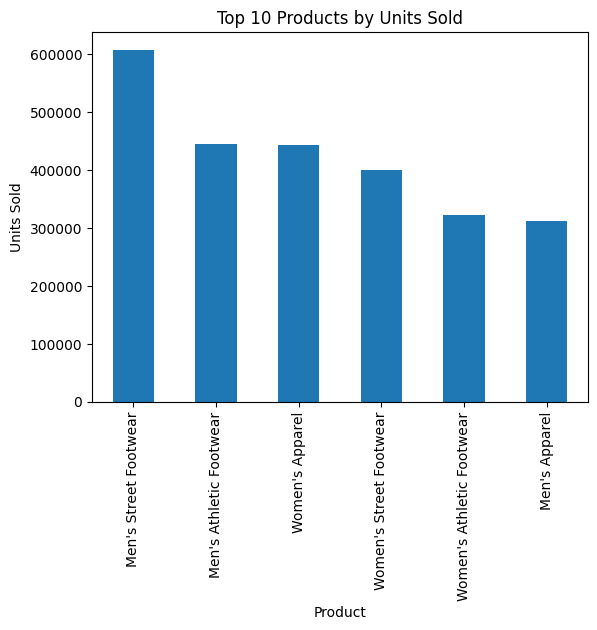

In [24]:
# Top 10 products by units sold
product_units = full_df.groupby("PRODUCT_NAME")["UNITS_SOLD"].sum().sort_values(ascending=False)
top_products = product_units.head(10)

top_products.plot(kind="bar", title="Top 10 Products by Units Sold")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.show()

**Answering the Business Questions**

What product category (product) had the highest sales (in dollars) in 2021? How much did it sell? <br>
*Men's Street Footwear	with a revenue of $75274716.0 and 509,119 units sold.*

In [25]:
full_df_2021 = full_df[full_df["YEAR"] == 2021]
product_category_sales = full_df_2021.groupby("PRODUCT_NAME")["REVENUE"].sum().sort_values(ascending=False)
product_category_units = full_df_2021.groupby("PRODUCT_NAME")["UNITS_SOLD"].sum().sort_values(ascending=False)
product_category_sales

,REVENUE
PRODUCT_NAME,
Men's Street Footwear,75274716.0
Women's Apparel,19658904.0
Men's Athletic Footwear,16702706.0
Women's Street Footwear,13807909.0
Men's Apparel,13325861.0
Women's Athletic Footwear,11381041.0


In [26]:
product_category_units

,UNITS_SOLD
PRODUCT_NAME,
Men's Street Footwear,509119
Women's Apparel,363672
Men's Athletic Footwear,362778
Women's Street Footwear,324294
Women's Athletic Footwear,258860
Men's Apparel,251656


What state had the highest sales (in dollars) of women's products in 2021? How much was it? <br>
*Maine with $2,176,301.0 in revenue.*


In [28]:
#checking how to identify women's products
print(full_df_2021["PRODUCT_NAME"].unique())

["Men's Street Footwear" "Men's Athletic Footwear" "Men's Apparel"
 "Women's Street Footwear" "Women's Athletic Footwear" "Women's Apparel"]


In [29]:
womens_df = full_df_2021[full_df_2021["PRODUCT_NAME"].str.contains("Women's")]
womens_state_sales = womens_df.groupby("STATE")["REVENUE"].sum().sort_values(ascending=False)
womens_state_sales

,REVENUE
STATE,
Maine,2176301.0
Delaware,2023575.0
New Hampshire,1916400.0
Arizona,1798900.0
Missouri,1771992.0
Illinois,1743277.0
New York,1736862.0
Virginia,1719886.0
Nebraska,1712680.0


What state had the highest sales (in dollars) of men's products in 2021? How much was it? <br>
*New Hampshire with 54,208,080.0 in revenue.*

In [30]:
mens_df = full_df_2021[full_df_2021["PRODUCT_NAME"].str.contains("Men's")]
mens_state_sales = mens_df.groupby("STATE")["REVENUE"].sum().sort_values(ascending=False)
mens_state_sales

,REVENUE
STATE,
New Hampshire,54208080.0
Delaware,2334300.0
Arizona,2261025.0
Maine,2217190.0
New York,2114999.0
Illinois,2093438.0
Missouri,1951530.0
Connecticut,1926568.0
Nebraska,1718726.0


What retailer purchased the most units in 2021?
*Foot Locker with 1,097,410 units sold.*

In [31]:
full_df_2021.groupby("RETAILER")["UNITS_SOLD"].sum().sort_values(ascending=False)

,UNITS_SOLD
RETAILER,
Foot Locker,1097410
West Gear,315502
Sports Direct,256363
Amazon,205570
Kohl's,136950
Walmart,58286


What retailer purchased the most units in 2020? <br>
*Amazon with 317,930 units sold.*


In [32]:
full_df_2020 = full_df[full_df["YEAR"] == 2020]
full_df_2020.groupby("RETAILER")["UNITS_SOLD"].sum().sort_values(ascending=False)

,UNITS_SOLD
RETAILER,
Amazon,317930
Kohl's,68686
West Gear,57334
Sports Direct,18399
